In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path

TARGET_CRS = "EPSG:5070"

In [4]:

folder = Path("./elections/candidate_totals_by_county")

IllinoisElectionResultsByCounty = {}

for file in folder.iterdir():
    IllinoisElectionResultsByCounty[file.name] = pd.read_csv(file)

In [5]:
folder = Path("./maps/raw/historical_districts_by_state/IL")

Illinois = {}

for file in folder.iterdir():
    Illinois[file.name] = gpd.read_file(file).to_crs(TARGET_CRS)

In [6]:
ILTracts2020 = gpd.read_file('./maps/raw/historical_census_tracts_by_state/tracts_2022/Illinois_tl_2022_17_tract/tl_2022_17_tract.shp').to_crs(TARGET_CRS)
ILRoads2025 = gpd.read_file('./maps/raw/IL/tl_2025_17_prisecroads/tl_2025_17_prisecroads.shp').to_crs(TARGET_CRS)
ILPlaces2025 = gpd.read_file('./maps/raw/IL/tl_2025_17_place/tl_2025_17_place.shp').to_crs(TARGET_CRS)
ILTollways2025 = gpd.read_file("./maps/raw/IL/TollwayReferenceLines.gdb").to_crs(TARGET_CRS)
ILCounties = gpd.read_file("./maps/raw/counties_by_state/IL.geojson").to_crs(TARGET_CRS)
ILCollarCountiesArea = gpd.read_file("./maps/raw/IL/IL_ChicagoCollarCountiesArea.geojson").to_crs(TARGET_CRS)
ILMidStateArea = gpd.read_file("./maps/raw/IL/IL_MidStateArea.geojson").to_crs(TARGET_CRS)
ILSTLArea = gpd.read_file("./maps/raw/IL/IL_STLArea.geojson").to_crs(TARGET_CRS)
ChicagoCommunityAreas = gpd.read_file("./maps/raw/Chicago/ChicagoCommunityAreas.geojson").to_crs(TARGET_CRS)

c:\Users\Wayne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured MultiLineString' is converted to 'MultiLineString'
  return ogr_read(
c:\Users\Wayne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'TollwayReferenceLines.gdb': 'NewReferenceLine' (default), 'ReferenceLine'. Specify layer parameter to avoid this warning.
  result = read_func(


In [7]:
ILCounties[(
    (ILCounties['NAME'].isin(['MONROE', 'ST. CLAIR', 'MADISON']))
)].to_file("IL_STLArea.geojson")

In [8]:
ChicagoCommunityAreas['NAME'] = ChicagoCommunityAreas['community']

In [9]:
# ILPlaces2025_WithChicagoCommunityAreas

ILPlaces2025_WithChicagoCommunityAreas = gpd.GeoDataFrame(
    pd.concat(
        [ILPlaces2025, ChicagoCommunityAreas],
        ignore_index=True
    ),
    geometry="geometry",
    crs=ILPlaces2025.crs
)

ILPlaces2025_WithChicagoCommunityAreas = ILPlaces2025_WithChicagoCommunityAreas[(
    (ILPlaces2025_WithChicagoCommunityAreas['NAME'] != 'Chicago')
)]

In [10]:
lines = ILRoads2025[(
    (ILRoads2025['RTTYP'] == 'I')
    | (ILRoads2025['RTTYP'] == 'U')
)].reset_index(drop=True).copy()

lines = lines.dissolve(
    by="FULLNAME",
    as_index=False
)

# lines = your MultiLineString GeoDataFrame

# Find candidate intersecting pairs
left_idx, right_idx = lines.sindex.query(
    lines.geometry,
    predicate="intersects"
)

# Remove self-intersections and duplicate pairs
mask = left_idx < right_idx
left_idx = left_idx[mask]
right_idx = right_idx[mask]

# Calculate intersections
intersections = []

for i, j in zip(left_idx, right_idx):
    geom = lines.geometry.iloc[i].intersection(
        lines.geometry.iloc[j]
    )

    if geom.is_empty:
        continue

    # Extract points
    if geom.geom_type == "Point":
        intersections.append(geom)

    elif geom.geom_type == "MultiPoint":
        intersections.extend(list(geom.geoms))

    elif geom.geom_type == "GeometryCollection":
        intersections.extend(
            [
                g for g in geom.geoms
                if g.geom_type == "Point"
            ]
        )

# Create GeoDataFrame
ILInterstateIntersections2026 = gpd.GeoDataFrame(
    geometry=intersections,
    crs=lines.crs
)

# Remove duplicate intersection points
ILInterstateIntersections2026 = (
    ILInterstateIntersections2026
    .drop_duplicates(subset="geometry")
    .reset_index(drop=True)
)

In [11]:
# Get all places within 1 mile buffer of interstate highways

ILRoads2025_Interstates_1MileBuffer = ILRoads2025[(
    (ILRoads2025['RTTYP'] == 'I')
    #  | (ILRoads2025['RTTYP'] == 'U')
)].copy()
ILRoads2025_Interstates_1MileBuffer["geometry"] = ILRoads2025_Interstates_1MileBuffer.geometry.buffer(1609.344)

ILPlaces2025_IntersectsWithILInterstates = gpd.sjoin(
    ILPlaces2025_WithChicagoCommunityAreas,
    ILRoads2025_Interstates_1MileBuffer[["geometry"]],
    how="inner",
    predicate="intersects"
)

In [12]:
# Get all places within 1 mile buffer of interstate highways

ILRoads2025_USHighways_1MileBuffer = ILRoads2025[(
    (ILRoads2025['RTTYP'] == 'I')
     | (ILRoads2025['RTTYP'] == 'U')
)].copy()
ILRoads2025_USHighways_1MileBuffer["geometry"] = ILRoads2025_USHighways_1MileBuffer.geometry.buffer(1609.344)

ILPlaces2025_IntersectsWithUSHighways = gpd.sjoin(
    ILPlaces2025_WithChicagoCommunityAreas,
    ILRoads2025_USHighways_1MileBuffer[["geometry"]],
    how="inner",
    predicate="intersects"
)

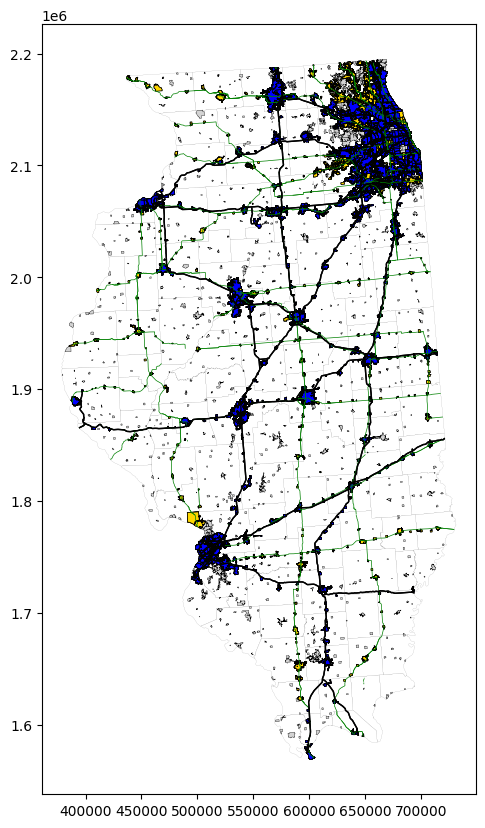

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))

colors = {
    "I": "red",       # Interstate
    "U": "orange",    # US Highway
    "S": "gold",      # State
    "C": "green",     # County
    "M": "purple",    # Military
    "O": "gray",      # Other
}

# for rttyp, group in ILRoads2025.groupby("RTTYP"):

#     ILRoads2025.plot(
#         ax=ax,
#         edgecolor=colors[rttyp],
#         linewidth=0.5,
#         label="IL-8",
#     )


ILCounties.plot(
    ax=ax,
    color='#fff',
    edgecolor='black',
    linewidth=0.05,
    label="IL-8", 
)

# ILRoads2025[(
#     (ILRoads2025['RTTYP'] == 'S')
# )].plot(
#     ax=ax,
#     edgecolor='gold',
#     linewidth=1,
#     label="IL-8",
# )

ILRoads2025[(
    (ILRoads2025['RTTYP'] == 'U')
)].plot(
    ax=ax,
    edgecolor='green',
    linewidth=0.5,
    label="IL-8",
)

ILRoads2025[(
    (ILRoads2025['RTTYP'] == 'I')
)].plot(
    ax=ax,
    edgecolor='black',
    linewidth=1,
    label="IL-8",
)

ILPlaces2025_WithChicagoCommunityAreas.plot(
    ax=ax,
    edgecolor='black',
    color="lightgrey",
    linewidth=0.25,
    label="IL-8",
)

ILPlaces2025_IntersectsWithUSHighways.plot(
    ax=ax,
    edgecolor='black',
    color="gold",
    linewidth=0.5,
    label="IL-8",
)


ILPlaces2025_IntersectsWithILInterstates.plot(
    ax=ax,
    edgecolor='black',
    color="blue",
    linewidth=0.5,
    label="IL-8",
)

# minx, miny, maxx, maxy = ILMidStateArea.total_bounds

# ax.set_xlim(minx, maxx)
# ax.set_ylim(miny, maxy)


# plt.legend()
# plt.title("Precincts by Overlapping City")
plt.show()

In [14]:
import geopandas as gpd
from sklearn.cluster import DBSCAN

# Make sure points are in a projected CRS
points = ILInterstateIntersections2026.copy()

# Convert point geometries to x/y coordinates
coords = [
    [point.x, point.y]
    for point in points.geometry
]

# Cluster points within 100 feet
model = DBSCAN(
    eps=2 * 1609.344,       # maximum distance between points in a cluster
    min_samples=1  # at least 2 points to form a cluster
)

points["cluster"] = model.fit_predict(coords)

In [15]:
# One representative point per cluster
cluster_reps = (
    points
    .dissolve(by="cluster")
    .geometry
    .centroid
    .reset_index(name="geometry")
)

cluster_reps = gpd.GeoDataFrame(
    cluster_reps,
    geometry="geometry",
    crs=points.crs
)

# Find the closest place to each cluster representative point
cluster_labels = gpd.sjoin_nearest(
    cluster_reps,
    ILPlaces2025_WithChicagoCommunityAreas[["NAME", "geometry"]],
    how="left",
    distance_col="distance_to_place"
)

# Use the closest place name as the label
cluster_labels["label"] = cluster_labels["NAME"]


In [16]:
cluster_labels

,cluster,geometry,index_right,NAME,distance_to_place,label
0,0,POINT (501964.097 1935996.786),22,Havana,0.000000,Havana
1,1,POINT (508993.823 1936498.052),56,Topeka,3807.293222,Topeka
2,2,POINT (603681.417 2178878.662),670,Harvard,0.000000,Harvard
3,3,POINT (479656.579 2003432.953),183,Knoxville,1185.137896,Knoxville
4,4,POINT (718947.001 1854802.654),1285,Marshall,9016.862565,Marshall
...,...,...,...,...,...,...
152,152,POINT (595445.495 1884912.253),1361,Elwin,19.099529,Elwin
153,153,POINT (628337.756 2065872.389),209,Morris,0.000000,Morris
154,154,POINT (623612.123 2065175.16),209,Morris,0.000000,Morris
155,155,POINT (446074.728 1979435.511),864,Roseville,1330.687592,Roseville


In [ ]:
import geopandas as gpd
import numpy as np
from sklearn.cluster import DBSCAN

# --------------------------------------------------
# Settings
# --------------------------------------------------

DISTANCE_MILES = 15
DISTANCE_METERS = DISTANCE_MILES * 1609.344

# Work in a projected CRS
gdf = cluster_labels.to_crs("EPSG:5070").copy()


# --------------------------------------------------
# Cluster points separately for each NAME
# --------------------------------------------------

# Use an object column because cluster IDs will be strings
gdf["spatial_cluster"] = None

for name, group in gdf.groupby(
    "NAME",
    dropna=False,
):

    # Get point X/Y coordinates
    coordinates = np.column_stack(
        [
            group.geometry.x,
            group.geometry.y,
        ]
    )

    # Cluster points within 15 miles
    dbscan = DBSCAN(
        eps=DISTANCE_METERS,
        min_samples=1,
        metric="euclidean",
    )

    labels = dbscan.fit_predict(
        coordinates
    )

    # Create a unique cluster ID for each NAME
    cluster_ids = [
        f"{name}_{label}"
        for label in labels
    ]

    # Assign the cluster IDs
    gdf.loc[
        group.index,
        "spatial_cluster"
    ] = cluster_ids


# --------------------------------------------------
# Dissolve by NAME and spatial cluster
# --------------------------------------------------

dissolved = (
    gdf
    .dissolve(
        by=[
            "NAME",
            "spatial_cluster",
        ],
        as_index=False,
    )
)


# --------------------------------------------------
# Replace dissolved geometry with its centroid
# --------------------------------------------------

dissolved["geometry"] = (
    dissolved.geometry.centroid
)


# Return to the original CRS
dissolved = dissolved.to_crs(
    cluster_labels.crs
)

dissolved


TypeError: Invalid value '['ARMOUR SQUARE_0']' for dtype 'int64'

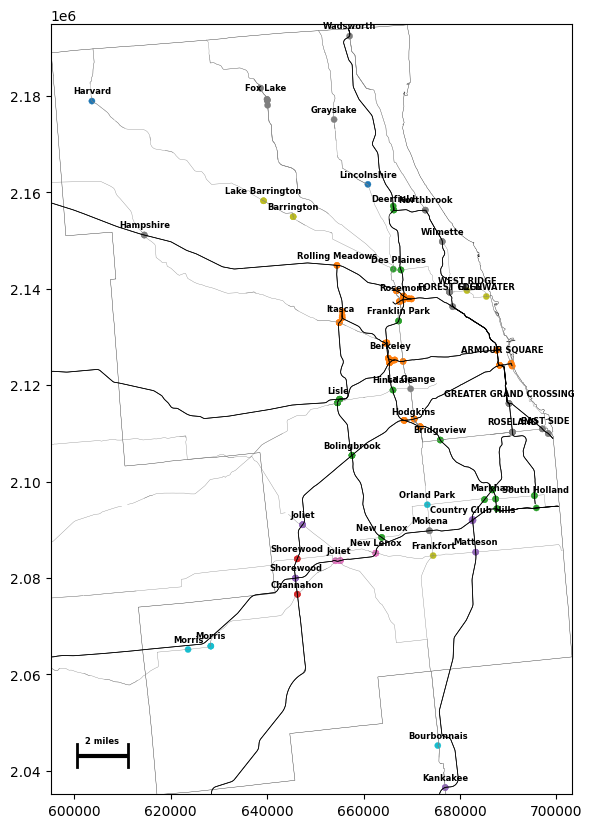

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

colors = {
    "I": "red",       # Interstate
    "U": "orange",    # US Highway
    "S": "gold",      # State
    "C": "green",     # County
    "M": "purple",    # Military
    "O": "gray",      # Other
}

# for rttyp, group in ILRoads2025.groupby("RTTYP"):

#     ILRoads2025.plot(
#         ax=ax,
#         edgecolor=colors[rttyp],
#         linewidth=0.5,
#         label="IL-8",
#     )

ILCollarCountiesArea.plot(
    ax=ax,
    linewidth=0.25,
    edgecolor="#000",
    color='#fff'
)

ILMidStateArea.plot(
    ax=ax,
    linewidth=0.25,
    edgecolor="#000",
    color='#fff'
)



# One geometry per cluster
cluster_areas = points.dissolve(by="cluster")

# Get one label location per cluster
cluster_areas["label_point"] = cluster_areas.geometry.centroid

points.plot(
    ax=ax,
    column=points['cluster'],
    categorical=True,
    legend=True,
    markersize=20,
    linewidth=0.25,
)

# Add one label per cluster
# for cluster_id, row in cluster_areas.iterrows():
#     x = row["label_point"].x
#     y = row["label_point"].y

#     ax.annotate(
#         str(cluster_id),
#         xy=(x, y),
#         ha="center",
#         va="center",
#         fontsize=10,
#         fontweight="bold",
#     )

for _, row in cluster_labels.iterrows():
    ax.annotate(
        text=row["NAME"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=6,
        fontweight="bold",
    )


minx, miny, maxx, maxy = ILCollarCountiesArea.total_bounds

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

if ax.get_legend() is not None:
    ax.get_legend().remove()


# Get current map extent
minx, maxx = ax.get_xlim()
miny, maxy = ax.get_ylim()

# Scale-bar length
scale_length = 2 * 5280  # 2 miles in feet

# Position near the bottom-left
x_start = minx + (maxx - minx) * 0.05
y_pos = miny + (maxy - miny) * 0.05

# Draw the scale line
ax.plot(
    [x_start, x_start + scale_length],
    [y_pos, y_pos],
    color="black",
    linewidth=3,
    solid_capstyle="butt",
)

# Add end ticks
tick_height = (maxy - miny) * 0.015

ax.plot(
    [x_start, x_start],
    [y_pos - tick_height, y_pos + tick_height],
    color="black",
    linewidth=2,
)

ax.plot(
    [x_start + scale_length, x_start + scale_length],
    [y_pos - tick_height, y_pos + tick_height],
    color="black",
    linewidth=2,
)

ILRoads2025[(
    ILRoads2025['RTTYP'] == 'U'
)].plot(
    ax=ax,
    edgecolor="grey",
    linewidth=0.25
)

ILRoads2025[(
    ILRoads2025['RTTYP'] == 'I'
)].plot(
    ax=ax,
    edgecolor="#000",
    linewidth=0.5
)

# Add label
ax.annotate(
    "2 miles",
    xy=(x_start + scale_length / 2, y_pos),
    xytext=(0, 8),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=6,
    fontweight="bold",
)
# plt.legend()
# plt.title("Precincts by Overlapping City")
plt.show()

In [18]:
import networkx as nx
from shapely.geometry import Point

# Use a projected CRS so distances are meaningful
places = cluster_labels.to_crs("EPSG:5070")

highways = ILRoads2025[
    (ILRoads2025["RTTYP"] == "I")
    | (ILRoads2025["RTTYP"] == "U")
].to_crs("EPSG:5070")

G = nx.Graph()

# --------------------------------------------------
# Add highway nodes and edges
# --------------------------------------------------

for idx, row in highways.iterrows():
    line = row.geometry

    # Ignore empty or invalid geometries
    if line is None or line.is_empty:
        continue

    # Handle MultiLineStrings if they exist
    if line.geom_type == "MultiLineString":
        lines = list(line.geoms)
    else:
        lines = [line]

    for segment in lines:

        # Get the start and end coordinates
        start = tuple(segment.coords[0])
        end = tuple(segment.coords[-1])

        # Add highway endpoint nodes
        G.add_node(
            start,
            node_type="highway",
        )

        G.add_node(
            end,
            node_type="highway",
        )

        # Add a highway edge
        G.add_edge(
            start,
            end,
            length=segment.length,
            highway_id=idx,
            geometry=segment,
            edge_type="highway",
        )


# --------------------------------------------------
# Add places with their NAME
# --------------------------------------------------

# Save the highway nodes before adding place nodes
highway_nodes = [
    node
    for node, data in G.nodes(data=True)
    if data.get("node_type") == "highway"
]

for idx, row in places.iterrows():

    point = row.geometry

    # Create a unique graph ID that cannot conflict
    # with highway coordinate tuples
    place_node = f"place_{idx}"

    # Add the place and save NAME as a node attribute
    G.add_node(
        place_node,
        node_type="place",
        NAME=row["NAME"],
        geometry=point,
    )

    # Find the closest highway graph node
    nearest_highway_node = min(
        highway_nodes,
        key=lambda node: point.distance(Point(node)),
    )

    # Connect the place to the highway network
    connector_distance = point.distance(
        Point(nearest_highway_node)
    )

    G.add_edge(
        place_node,
        nearest_highway_node,
        length=connector_distance,
        edge_type="place_connector",
    )


print(f"Nodes: {G.number_of_nodes():,}")
print(f"Edges: {G.number_of_edges():,}")


Nodes: 1,291
Edges: 1,194


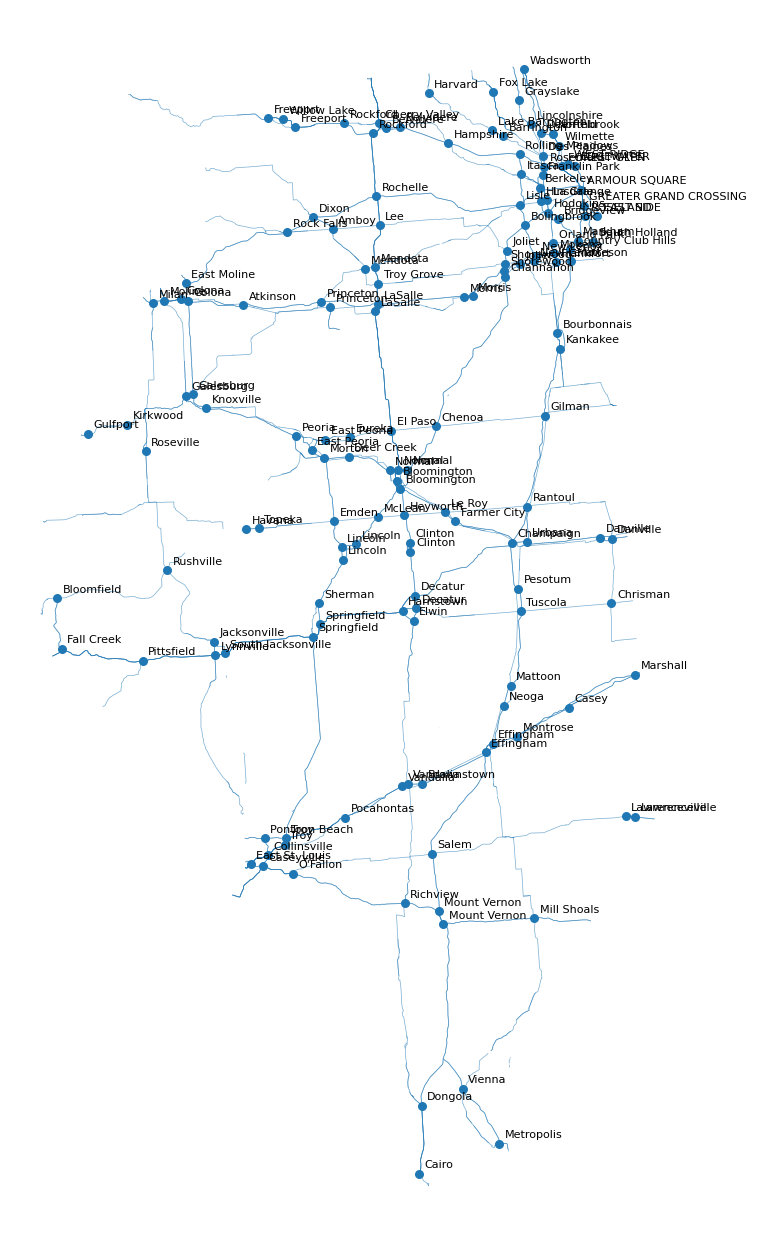

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 16))

# Draw the original highway geometry
highways.plot(
    ax=ax,
    linewidth=0.5,
    alpha=0.6,
)

# Draw places
places.plot(
    ax=ax,
    markersize=30,
)

# Add place names
for idx, row in places.iterrows():

    point = row.geometry

    ax.annotate(
        text=row["NAME"],
        xy=(point.x, point.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_aspect("equal")
ax.set_axis_off()

plt.show()

In [ ]:
import random

# Select a random node that has a NAME
named_nodes = [
    node
    for node, data in G.nodes(data=True)
    if data.get("NAME") is not None
]

current_node = random.choice(named_nodes)


def get_node_name(node):
    """
    Return NAME if the node has one.
    Otherwise, do not display coordinate tuples.
    """
    return G.nodes[node].get(
        "NAME",
        "[Highway node]",
    )


while True:

    # Get adjacent nodes
    neighbors = list(G.neighbors(current_node))

    # Display the current node's NAME
    print("\n" + "=" * 60)
    print(f"Current node: {get_node_name(current_node)}")
    print("=" * 60)

    if not neighbors:
        print("This node has no adjacent nodes.")
        break

    print("\nAdjacent nodes:")

    # Display each adjacent node
    for number, neighbor in enumerate(
        neighbors,
        start=1,
    ):
        print(
            f"{number}. {get_node_name(neighbor)}"
        )

    print("\nEnter a number to move.")
    print("Enter 'q' to quit.")

    choice = input("\nChoice: ").strip().lower()

    if choice == "q":
        print(
            f"\nFinished at: "
            f"{get_node_name(current_node)}"
        )
        break

    try:
        choice_number = int(choice)

        if not 1 <= choice_number <= len(neighbors):
            print(
                f"Enter a number from "
                f"1 to {len(neighbors)}."
            )
            continue

        # Move to the selected node
        current_node = neighbors[
            choice_number - 1
        ]

    except ValueError:
        print(
            "Enter a valid number or 'q'."
        )



Current node: (611325.7925983296, 2152089.044283175)

Adjacent nodes:
1. (597724.3084547337, 2156992.211190648)
2. (635133.4873032912, 2144221.844986139)

Enter a number to move.
Enter 'q' to quit.
